<h2 align="center">Most In-Demand Skills for the Top Three Data Careers</h2>

In [3]:
# Now we will look into likelihood of most in demand skills for data roles

# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleaning the data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [15]:
# now will look into data for India
df_IN = df[df['job_country']=="India"].copy()

# now we will explode the job_skills column so that it expands for each job role and provide skills associated in seperated rows
df_IN_skills = df_IN.explode('job_skills')

# now lets get for job title and job skill
df_IN_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
16,Data Engineer,powershell
16,Data Engineer,python
16,Data Engineer,sql
16,Data Engineer,mysql
16,Data Engineer,sql server
...,...,...
785716,Software Engineer,c#
785716,Software Engineer,sql
785718,Business Analyst,NaN
785740,Software Engineer,aws


In [89]:
# now lets create new dataframe using group by to group skill count based on skill name and job title
df_IN_skill_count = df_IN_skills.groupby(['job_skills','job_title_short']).size()

# now to convert into dataframe we have to reset the index and we name in 'skill count'
df_IN_skill_count = df_IN_skill_count.reset_index(name='skill_count')

# finally we have to sort the values by skill count in descending order
df_IN_skill_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_IN_skill_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
34,angular.js,Data Scientist,1
49,arch,Business Analyst,1
787,mlpack,Data Engineer,1
1679,yarn,Senior Data Scientist,1


In [76]:
# now from the df_IN_skills dataframe we will take top 3 roles, and convert them into a list
job_titles = df_IN_skills['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3], reverse=True)
job_titles

['Data Scientist', 'Data Engineer', 'Data Analyst']

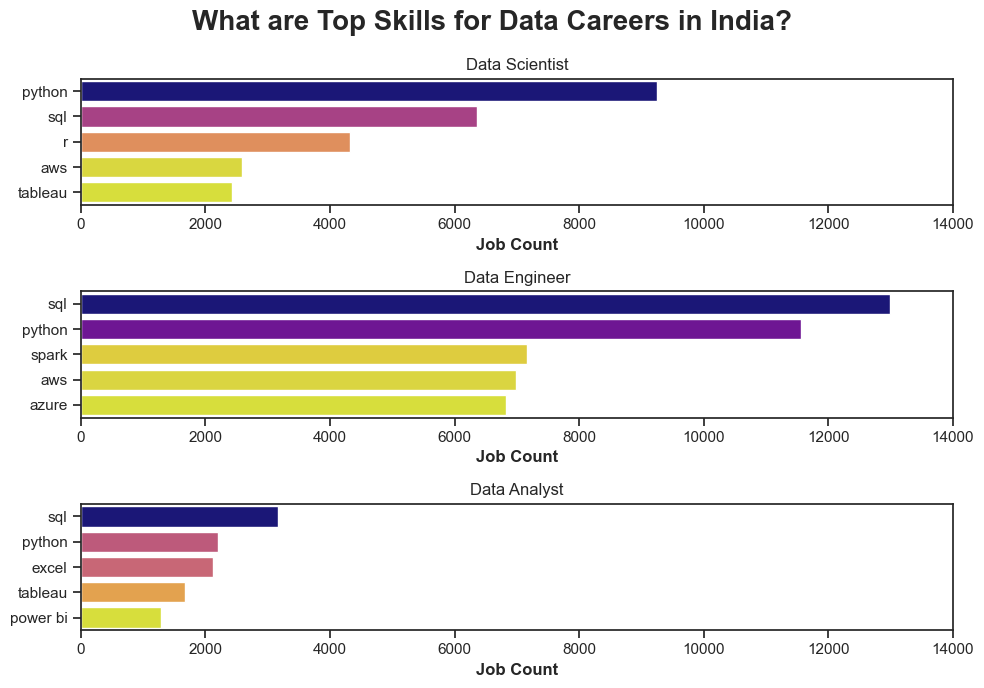

In [126]:
# now lets finally plot the above data
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10,7))
sns.set_theme(style='ticks')

# using loop for automation
for i, job_title in enumerate(job_titles):
    df_plot = df_IN_skill_count[df_IN_skill_count['job_title_short'] == job_title].head(5)[::-1]

    sns.barplot(
        data=df_plot,
        x='skill_count',
        y='job_skills',
        ax=ax[i],
        hue='skill_count',
        palette='plasma_r'
    )

    ax[i].set_title(job_title)
    ax[i].get_legend().remove()
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('Job Count',fontweight='bold')
    ax[i].set_xlim(0, 14000)
fig.suptitle('What are Top Skills for Data Careers in India?', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [86]:
# to make it more understandable we can calculate the likedlihood of skill appearing in job description
# for this we have to get total posting for different job titles
df_IN_title_count = df_IN['job_title_short'].value_counts().reset_index(name='total_jobs')

df_IN_title_count

,job_title_short,total_jobs
0,Data Engineer,19062
1,Data Scientist,13279
2,Data Analyst,6121
3,Senior Data Engineer,4353
4,Senior Data Scientist,2486
5,Business Analyst,1887
6,Software Engineer,1795
7,Senior Data Analyst,1083
8,Machine Learning Engineer,671
9,Cloud Engineer,351


In [93]:
# now we will merge df_IN_title_count and df_IN_skill_count based on job_title_short to see total job for a job role and divide it by the skill appeared in the JD
df_perc = pd.merge(df_IN_skill_count, df_IN_title_count, on='job_title_short', how='left')

# creating a new column called skill_percent to show likelihood
df_perc['skill_percent'] = (df_perc['skill_count']/df_perc['total_jobs'])*100
df_perc

,job_skills,job_title_short,skill_count,total_jobs,skill_percent
0,sql,Data Engineer,12993,19062,68.161788
1,python,Data Engineer,11568,19062,60.686182
2,python,Data Scientist,9248,13279,69.643798
3,spark,Data Engineer,7157,19062,37.545903
4,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...
1684,angular.js,Data Scientist,1,13279,0.007531
1685,arch,Business Analyst,1,1887,0.052994
1686,mlpack,Data Engineer,1,19062,0.005246
1687,yarn,Senior Data Scientist,1,2486,0.040225


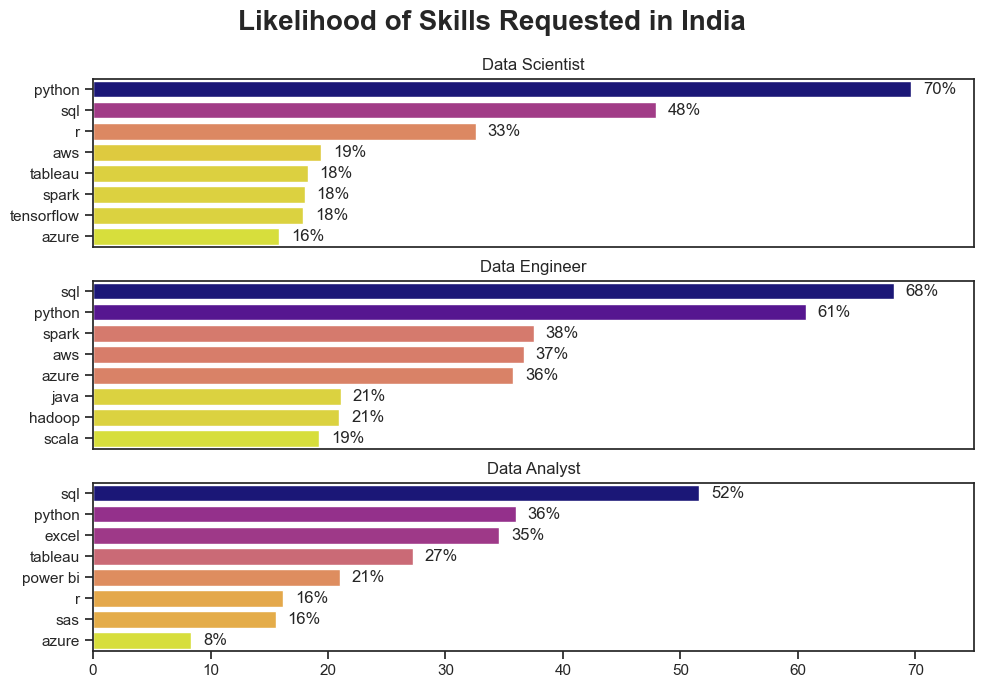

In [124]:
# final plotting
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10,7))


for i, job_title in enumerate(job_titles):
    df_plot = df_perc[df_perc['job_title_short'] == job_title].head(8)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='plasma_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 75)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in India', fontsize=20, fontweight='bold')
fig.tight_layout(h_pad=.8)
plt.show()